# Flight Data Analysis — Part 2: Touchdown Refinement via RBF Change-Point Detection

This notebook extends the spectral analysis from Part 1 by leveraging a broader set of FDR parameters to produce a refined touchdown timestamp. Where Part 1 relied on a z-score amplitude peak over the longitudinal accelerometer, this part uses a **kernel (RBF) change-point detector** applied to a multivariate feature space — Radio Altitude (RA), its time derivative (dRA/dt), and on-board accelerations — to identify the moment the aircraft transitions from the airborne regime to ground roll.

**Why RBF change-point detection?**  
Touchdown is fundamentally a **regime change**: RA drops toward zero, descent rate arrests, and the longitudinal/normal dynamics shift abruptly. An RBF kernel operates on pairwise distances in the joint feature space, detecting the *onset* of that distributional shift more robustly than any single-channel threshold or amplitude rule.

**Dataset:** `part2.csv` — FDR data from the Cranfield University Saab 340, with the following key columns:
- `CSDB Timestamp [s]` — strictly increasing time axis
- `Radio Altitude [ft]` — height above ground level
- `AC Normal Acceleration [g]` — vertical load factor
- `AC Longitudinal Acceleration [g]` — shared with Part 1

**Input from Part 1:** the acceleration-based provisional touchdown time `PART1_TOUCHDOWN_S`, used here as a comparison reference — not as ground truth.


## 0) Environment & Imports

The `ruptures` library provides the RBF kernel change-point detector. Run this cell once before the rest of the notebook.


In [1]:
!pip install ruptures numpy pandas matplotlib
## 0) Environment & imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Require ruptures for RBF change-point detection
import ruptures as rpt  # will raise ImportError if missing

# Matplotlib defaults
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.grid.which'] = 'both'
plt.rcParams['font.size'] = 10

print("✓ Imports complete.")
print("  ruptures available: True")


  Using cached matplotlib-3.10.8-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.7 MB)
ERROR: Could not install packages due to an OSError: [Errno 13] Permission denied: '/home/jupyter/environments/jupyterenv/lib/python3.10/site-packages/matplotlib/__init__.py'
Check the permissions.

✓ Imports complete.
  ruptures available: True


## 1) Configuration

The FDR CSV path, column names, and the Part 1 touchdown reference are set here. If the Part 1 notebook was run to completion, `PART1_TOUCHDOWN_S` is auto-loaded from `part1_touchdown_seconds.txt`. Otherwise it can be entered manually by uncommenting the override line below.

This value is used solely for comparison; Part 2 computes its own CPD estimate independently.


In [2]:
# 1) Configuration — paths, column names, and Part-1 touchdown

from pathlib import Path

# FDR dataset filename
FDR_CSV = Path("part2.csv")

# Column names
t_col  = "CSDB Timestamp [s]"               # Time (s)
ra_col = "Radio Altitude [ft]"              # Radio altitude (ft AGL)
az_col = "AC Normal Acceleration [g]"       # Normal (vertical) acceleration (optional but recommended)
ax_col = "AC Longitudinal Acceleration [g]" # Longitudinal acceleration (as in Part 1)

# --- Part-1 touchdown (seconds) ---
# Auto-load from Part-1 if available; otherwise set manually below.

PART1_TOUCHDOWN_S = None
pt1_file = Path("part1_touchdown_seconds.txt")

if pt1_file.exists():
    try:
        PART1_TOUCHDOWN_S = float(pt1_file.read_text().strip())
        source_str = f"loaded from {pt1_file.name}"
    except Exception as e:
        raise RuntimeError(f"Could not parse {pt1_file.name}: {e}")

# Manual override (uncomment if part1_touchdown_seconds.txt is not available):
# PART1_TOUCHDOWN_S = 3336.78  # <-- replace with your Part-1 value (seconds)
# source_str = "manual entry"

# Hard stop if still missing
assert PART1_TOUCHDOWN_S is not None, (
    "Part-1 touchdown time not provided.\n"
    "Run the final cell in Part-1 to create 'part1_touchdown_seconds.txt' OR "
    "uncomment and set PART1_TOUCHDOWN_S manually in this cell."
)

# Basic file presence check for the FDR CSV
assert FDR_CSV.exists(), f"FDR CSV not found at: {FDR_CSV.resolve()}"

print("Configuration:")
print(f"  FDR_CSV:              {FDR_CSV}")
print(f"  Columns:              t='{t_col}', RA='{ra_col}', AZ='{az_col}', AX='{ax_col}'")
print(f"  Part-1 touchdown:     {PART1_TOUCHDOWN_S:.2f} s ({source_str})")


Configuration:
  FDR_CSV:              part2.csv
  Columns:              t='CSDB Timestamp [s]', RA='Radio Altitude [ft]', AZ='AC Normal Acceleration [g]', AX='AC Longitudinal Acceleration [g]'
  Part-1 touchdown:     3336.78 s (loaded from part1_touchdown_seconds.txt)


## 2) FDR Data Loading & QA/QC

The FDR CSV is loaded and validated: timestamp monotonicity, duplicate removal, NaN counts, sampling rate, gap detection, and Radio Altitude range. These checks confirm the data is suitable for CPD analysis and flag any issues before feature engineering.


In [3]:
# Load CSV
df = pd.read_csv(FDR_CSV)

# Verify required columns exist
missing = [c for c in (t_col, ra_col) if c not in df.columns]
assert not missing, f"Missing required column(s): {missing}"

print("FDR Data Load & QA/QC")
print("="*60)
print(f"\nRows loaded: {len(df)}")
print(f"Columns: {list(df.columns[:15])}...")  # First 15 columns

# Drop duplicates and sort by timestamp
n_before = len(df)
df = df.drop_duplicates(subset=[t_col]).sort_values(t_col).reset_index(drop=True)
n_after = len(df)
print(f"\nDuplicate timestamps: {n_before - n_after} (removed)")
assert df[t_col].is_monotonic_increasing, "Timestamps must be strictly increasing."

# Check for NaNs
n_nan_t  = df[t_col].isna().sum()
n_nan_ra = df[ra_col].isna().sum()
print(f"\nNaNs:")
print(f"  Timestamp:        {n_nan_t}")
print(f"  Radio Altitude:   {n_nan_ra}")
assert n_nan_t == 0, "Timestamp contains NaNs."
# RA NaNs can exist briefly; warn only:
if n_nan_ra > 0:
    print(f"  WARNING: RA has {n_nan_ra} NaNs (will be ignored downstream).")

# Sampling rate and duration
t_vals = df[t_col].to_numpy()
dt = np.diff(t_vals)
assert len(dt) > 0, "Not enough rows to compute sampling."
dt_med = float(np.median(dt))
fs_med = float(1.0 / dt_med) if dt_med > 0 else float("nan")

print(f"\nSampling:")
print(f"  Median dt: {dt_med:.6f} s")
print(f"  Approximate fs: {fs_med:.2f} Hz")
print(f"  Min dt: {np.min(dt):.6f} s, Max dt: {np.max(dt):.6f} s")
print(f"  Duration: {t_vals[-1] - t_vals[0]:.1f} s (~{(t_vals[-1]-t_vals[0])/60:.1f} min)")
assert dt_med > 0, "Median dt must be > 0."

# Check for large gaps
large_gaps = np.where(dt > 3*dt_med)[0]
if len(large_gaps) > 0:
    print(f"  WARNING: {len(large_gaps)} large gaps detected (>3× median dt)")
else:
    print(f"  No large gaps detected.")

# Radio Altitude range
ra_vals = df[ra_col].to_numpy()
print(f"\nRadio Altitude range: {np.min(ra_vals):.0f} to {np.max(ra_vals):.0f} ft")
if np.min(ra_vals) < -100 or np.max(ra_vals) > 50000:
    print("  WARNING: Unusual RA range – check units/encoding")

# Preview data
print(f"\nData preview (first 5 rows):")
preview_cols = [t_col, ra_col]
if az_col in df.columns: preview_cols.append(az_col)
if ax_col in df.columns: preview_cols.append(ax_col)
print(df[preview_cols].head())

print(f"\n✓ QA/QC complete.")


FDR Data Load & QA/QC

Rows loaded: 25211
Columns: ['Analogue Input Timestamp [s]', 'CSDB Timestamp [s]', 'Longitudinal Acceleration [g]', 'Normal Acceleration [g]', 'AC Normal Acceleration [g]', 'AC Longitudinal Acceleration [g]', 'Pressure Altitude [ft]', 'Radio Altitude [ft]']...

Duplicate timestamps: 0 (removed)

NaNs:
  Timestamp:        0
  Radio Altitude:   0

Sampling:
  Median dt: 0.021400 s
  Approximate fs: 46.73 Hz
  Min dt: 0.019500 s, Max dt: 0.025400 s
  Duration: 517.0 s (~8.6 min)
  No large gaps detected.

Radio Altitude range: 0 to 2409 ft

Data preview (first 5 rows):
   CSDB Timestamp [s]  Radio Altitude [ft]  AC Normal Acceleration [g]  \
0           2834.2828               2282.0                      1.0006   
1           2834.3043               2282.0                      1.0006   
2           2834.3239               2282.0                      0.9984   
3           2834.3453               2282.0                      0.9961   
4           2834.3649             

## 3) Part 1 Touchdown Reference

The provisional touchdown time from Part 1 is confirmed here and located within the FDR time axis. It serves as the centre of the segmentation window in the next step and as the comparison baseline for the CPD result.


In [4]:
# Confirm Part-1 touchdown reference (no fallback here)
t_part1 = float(PART1_TOUCHDOWN_S)

print("Touchdown Reference (from Part 1)")
print("="*60)
print(f"t_part1 = {t_part1:.2f} s")
print(f"Time in this FDR record: {t_part1 - t_vals[0]:.1f} s from start")

# (Optional, non-intrusive) map to nearest FDR index for quick cross-checks downstream
import numpy as np
idx_part1 = int(np.argmin(np.abs(t_vals - t_part1)))
print(f"Nearest FDR index: {idx_part1} (t = {t_vals[idx_part1]:.2f} s)")


Touchdown Reference (from Part 1)
t_part1 = 3336.78 s
Time in this FDR record: 502.5 s from start
Nearest FDR index: 24501 (t = 3336.78 s)


## 4) Segmentation Around Landing

CPD applied to the full flight would pick up other regime changes (top-of-descent, flare, etc.). A ±60 s window centred on the Part 1 estimate focuses the detector on the landing phase and makes the output directly interpretable.

The window bounds can be adjusted if the segment is too short (< 30 s) or if RA never approaches ground within it. The effective duration and RA range are printed for verification.


In [5]:
# Segmentation window around Part 1 touchdown
# Time window around Part-1 touchdown (seconds)
window_pre  = 60.0
window_post = 60.0

# Optional diagnostic threshold: how many samples in the segment are below this RA
ra_threshold = 500.0  # ft (diagnostic; we do NOT filter by it here)

# --- Build time-window segment
t_start_seg = float(t_part1 - window_pre)
t_end_seg   = float(t_part1 + window_post)

mask_seg = (df[t_col] >= t_start_seg) & (df[t_col] <= t_end_seg)
df_seg = df.loc[mask_seg].copy()

if len(df_seg) == 0:
    raise ValueError("Segmentation produced no data. Check your Part-1 touchdown time and the window settings.")

# Report
print("Data Segmentation for RBF CPD")
print("="*60)
print("\nSegmentation strategy:")
print("  Method: Time window around Part-1 touchdown")
print(f"  Pre-window:  {window_pre:.1f} s")
print(f"  Post-window: {window_post:.1f} s")

t_seg = df_seg[t_col].to_numpy()
print("\nSegmented data:")
print(f"  Start time: {t_seg[0]:.2f} s")
print(f"  End time:   {t_seg[-1]:.2f} s")
print(f"  Duration:   {t_seg[-1] - t_seg[0]:.1f} s")
print(f"  Samples:    {len(df_seg)}")

# RA diagnostics (no filtering here; just informative)
ra_seg = df_seg[ra_col].to_numpy()
print("\nRadio Altitude in segment:")
print(f"  Min:  {np.nanmin(ra_seg):.0f} ft")
print(f"  Max:  {np.nanmax(ra_seg):.0f} ft")
print(f"  Mean: {np.nanmean(ra_seg):.0f} ft")

n_below = int(np.sum(ra_seg < ra_threshold))
print(f"\nSamples with RA < {ra_threshold:.0f} ft (diagnostic): {n_below}/{len(ra_seg)}")

# Basic sanity warnings that DO NOT stop execution
dur_seg = float(t_seg[-1] - t_seg[0])
if dur_seg < 30:
    print("  WARNING: Very short segment (<30 s). CPD may be noisy; widen window_pre/post if possible.")
if np.nanmin(ra_seg) > 50:
    print("  WARNING: RA never approaches ground in this segment (min > 50 ft). Verify your window.")


Data Segmentation for RBF CPD

Segmentation strategy:
  Method: Time window around Part-1 touchdown
  Pre-window:  60.0 s
  Post-window: 60.0 s

Segmented data:
  Start time: 3276.79 s
  End time:   3351.33 s
  Duration:   74.5 s
  Samples:    3635

Radio Altitude in segment:
  Min:  0 ft
  Max:  602 ft
  Mean: 214 ft

Samples with RA < 500 ft (diagnostic): 3235/3635


## 5) Feature Engineering

Four features are constructed for the CPD:
- **RA** — raw radio altitude (ft), descending toward 0 at touchdown
- **dRA/dt** — time derivative of RA, capturing the rate-of-descent arrest
- **Az (normal acceleration)** — vertical load factor, impulsive at gear contact
- **Ax (longitudinal acceleration)** — deceleration profile during rollout

Each feature is z-scored independently so no single channel dominates the RBF distance computation. Isolated NaNs in RA are filled by linear interpolation within the segment.


In [6]:
# Extract time and RA from segmented data
t_seg = df_seg[t_col].to_numpy().astype(float)
ra_seg = df_seg[ra_col].to_numpy().astype(float)

# --- Minimal, safe handling of NaNs in RA (linear interpolation within segment)
if np.isnan(ra_seg).any():
    finite = np.isfinite(ra_seg)
    if finite.sum() >= 2:
        ra_seg = np.interp(t_seg, t_seg[finite], ra_seg[finite])
        print("  Note: RA contained NaNs; filled by linear interpolation within the segment.")
    else:
        raise ValueError("RA has insufficient finite samples in the segment.")

# Compute derivative of RA (ft/s)
dra_seg = np.gradient(ra_seg, t_seg)

# Build feature list (RA, dRA/dt always present)
X_features = [ra_seg, dra_seg]
feature_names = ['RA [ft]', 'd(RA)/dt [ft/s]']

# Add accelerations if available
if az_col in df_seg.columns:
    az_vals = df_seg[az_col].to_numpy().astype(float)
    X_features.append(az_vals)
    feature_names.append(az_col)

if ax_col in df_seg.columns:
    ax_vals = df_seg[ax_col].to_numpy().astype(float)
    X_features.append(ax_vals)
    feature_names.append(ax_col)

# Stack into feature matrix (N, d)
X = np.vstack(X_features).T

print("Feature Engineering for RBF CPD")
print("="*60)
print(f"\nFeatures included: {len(feature_names)}")
for i, name in enumerate(feature_names):
    print(f"  {i}: {name}")

print("\nRaw feature matrix:")
print(f"  Shape: {X.shape} (samples × dimensions)")
print("  Feature ranges:")
for i, name in enumerate(feature_names):
    xi = X[:, i]
    print(f"    {name}: [{np.nanmin(xi):.2f}, {np.nanmax(xi):.2f}]")

# Standardize (z-score) each feature
mu = np.nanmean(X, axis=0, keepdims=True)
sd = np.nanstd(X, axis=0, keepdims=True) + 1e-12  # avoid division by zero
Z = (X - mu) / sd

# Replace any remaining non-finite with 0 (benign for RBF distances)
if np.any(~np.isfinite(Z)):
    n_bad = int(np.sum(~np.isfinite(Z)))
    print(f"\nWARNING: {n_bad} non-finite standardized values detected; replacing with 0.")
    Z = np.nan_to_num(Z, nan=0.0, posinf=0.0, neginf=0.0)

# Report standardization quality
print("\nStandardized feature matrix Z (z-score by column):")
for i, name in enumerate(feature_names):
    print(f"    {name}: mean={np.mean(Z[:, i]):.4f}, std={np.std(Z[:, i]):.4f}")

print("\n✓ Feature engineering complete. Z is ready for CPD.")


Feature Engineering for RBF CPD

Features included: 4
  0: RA [ft]
  1: d(RA)/dt [ft/s]
  2: AC Normal Acceleration [g]
  3: AC Longitudinal Acceleration [g]

Raw feature matrix:
  Shape: (3635, 4) (samples × dimensions)
  Feature ranges:
    RA [ft]: [0.00, 602.12]
    d(RA)/dt [ft/s]: [-141.18, 58.07]
    AC Normal Acceleration [g]: [0.84, 1.26]
    AC Longitudinal Acceleration [g]: [-0.25, 0.02]

Standardized feature matrix Z (z-score by column):
    RA [ft]: mean=-0.0000, std=1.0000
    d(RA)/dt [ft/s]: mean=-0.0000, std=1.0000
    AC Normal Acceleration [g]: mean=0.0000, std=1.0000
    AC Longitudinal Acceleration [g]: mean=0.0000, std=1.0000

✓ Feature engineering complete. Z is ready for CPD.


## 6) RBF Kernel Change-Point Detection

The standardised feature matrix Z = [RA, dRA/dt, Az, Ax] is passed to `ruptures.KernelCPD` with an RBF kernel. A single change-point is requested (`n_bkps=1`), corresponding to the touchdown regime transition.

The RBF scale parameter γ is set automatically via the **median-distance heuristic** (γ = 1 / 2σ², where σ is the median pairwise distance in the feature space), following the recommendation in the ruptures documentation. This avoids ad hoc tuning and is validated by the sensitivity sweep in Section 8.

An additional **jerk-RMS feature** (short-window RMS of d(Az)/dt, ≈250 ms) is appended to make the detector responsive to the sharp impulsive onset at gear contact, and up-weighted ×3 relative to the other features.

**Interpreting the result:** the CPD time reflects the earliest *sustained* distributional shift across all features — RA flattening near 0 ft, dRA/dt crossing toward zero, and persistent deceleration — rather than the maximum amplitude of any single spike.


In [7]:
# 6) RBF kernel change-point detection (using the ruptures library linked above)

N_BKPS  = 1      # number of change-points (touchdown)
PENALTY = None   # keep None; we use N_BKPS
# -------------------------------------------

import numpy as np
import ruptures as rpt

def _auto_gamma_from_median_dist(Z, max_sample=500):
    """Median-distance heuristic: gamma = 1/(2*sigma^2), sigma ≈ median pairwise distance in Z."""
    n = len(Z)
    sel = np.random.choice(n, size=min(max_sample, n), replace=False)
    Zs = Z[sel]
    D = np.linalg.norm(Zs[:, None, :] - Zs[None, :, :], axis=2)
    valid = D[D > 0]
    sigma = np.median(valid) if valid.size else 1.0
    gamma = 1.0 / (2.0 * (sigma**2 + 1e-12))
    return float(gamma), float(sigma)

print("RBF Kernel Change-Point Detection (ruptures)")
print("="*60)

# Time resolution in the segment (used for ± uncertainty)
dt_seg = np.diff(t_seg)
dt_med_seg = float(np.median(dt_seg)) if len(dt_seg) else np.nan


# --- NEW: making CPD sensitive to the touchdown impulse (short transient) ---
# Impact feature: short-window RMS of vertical jerk (highlights the impact onset/peak)
az = df_seg[az_col].to_numpy()
jerk = np.gradient(az, dt_med_seg)

w = max(5, int(round(0.25 / dt_med_seg)))  # ~250 ms window (tunable 0.15–0.35 s)
td_feat = np.sqrt(np.convolve(jerk**2, np.ones(w)/w, mode="same"))

# Combine with existing features (keeps our pipeline intact)
Z_cpd = np.c_[Z, td_feat]

# Robust-ish standardization so no channel dominates distances
Z_cpd = (Z_cpd - np.median(Z_cpd, axis=0)) / (np.std(Z_cpd, axis=0) + 1e-9)

# Up-weight the touchdown feature so the optimizer can't ignore it
Z_cpd[:, -1] *= 3.0



# Choose gamma automatically (per ruptures' recommended practice)
gamma_used, sigma_est = _auto_gamma_from_median_dist(Z_cpd)
print(f"Auto gamma (median heuristic): gamma = {gamma_used:.6f}  (σ ≈ {sigma_est:.4f})")

# Run CPD with RBF kernel; pass gamma via params to CostRbf
algo = rpt.KernelCPD(kernel="rbf", params={"gamma": gamma_used}).fit(Z_cpd)

bkps = (algo.predict(pen=float(PENALTY))
        if PENALTY is not None
        else algo.predict(n_bkps=int(N_BKPS)))

# 'bkps' are 1-indexed end indices; final N is always included
N = len(Z)
cp_candidates = [b for b in bkps if b < N]
assert cp_candidates, f"No valid change-point (< {N}) returned by ruptures: {bkps}"
cp_1idx = int(cp_candidates[0])
idx_cpd = cp_1idx - 1  # convert to 0-based

# Map to time & report
t_cpd = float(t_seg[idx_cpd])
delta_vs_part1 = float(t_cpd - float(t_part1))

print("\nDetected change-point")
print(f"  Index (0-based): {idx_cpd}")
print(f"  Time:            {t_cpd:.2f} s")
print(f"  Kernel gamma:    {gamma_used:.6f}")
print(f"  Timing uncertainty (±): ≈ {dt_med_seg:.3f} s  (median Δt within segment)")
print(f"  Difference vs Part-1:   {delta_vs_part1:+.2f} s (CPD − Part-1)")

# Expose variables for later cells
CPD_INDEX = idx_cpd
CPD_TIME_S = t_cpd
CPD_GAMMA = gamma_used
CPD_DTIME_VS_PART1 = delta_vs_part1
CPD_T_UNCERT_S = dt_med_seg

print("\n✓ RBF CPD complete.")


RBF Kernel Change-Point Detection (ruptures)
Auto gamma (median heuristic): gamma = 0.044225  (σ ≈ 3.3624)

Detected change-point
  Index (0-based): 2658
  Time:            3331.31 s
  Kernel gamma:    0.044225
  Timing uncertainty (±): ≈ 0.021 s  (median Δt within segment)
  Difference vs Part-1:   -5.47 s (CPD − Part-1)

✓ RBF CPD complete.


## 7) Visualisation & Comparison with Part 1

Four panels overlay the RBF CPD time (red dashed) and the Part 1 estimate (green dotted) on the segmented FDR signals:
1. **Radio Altitude** — confirms whether CPD aligns with RA → 0 ft
2. **dRA/dt** — shows the descent-rate arrest
3. **Accelerations** — full segment view of Az and Ax
4. **Acceleration zoom** — ±3 s around CPD for detailed onset inspection

The time difference Δt = CPD − Part 1 is printed and contextualised: a negative Δt means CPD fires earlier (consistent with detecting the flare/gear-contact onset before the braking-dominated amplitude peak that Part 1 locked onto).


Visualizing CPD Result & Comparison with Part 1

Time difference (CPD - Part 1): -5.47 s
  → Significant difference (>5.5 s). Check which transient Part 1 locked onto.
  First RA ≤ 5 ft at t = 3329.61 s (CPD − RA5 = +1.70 s)


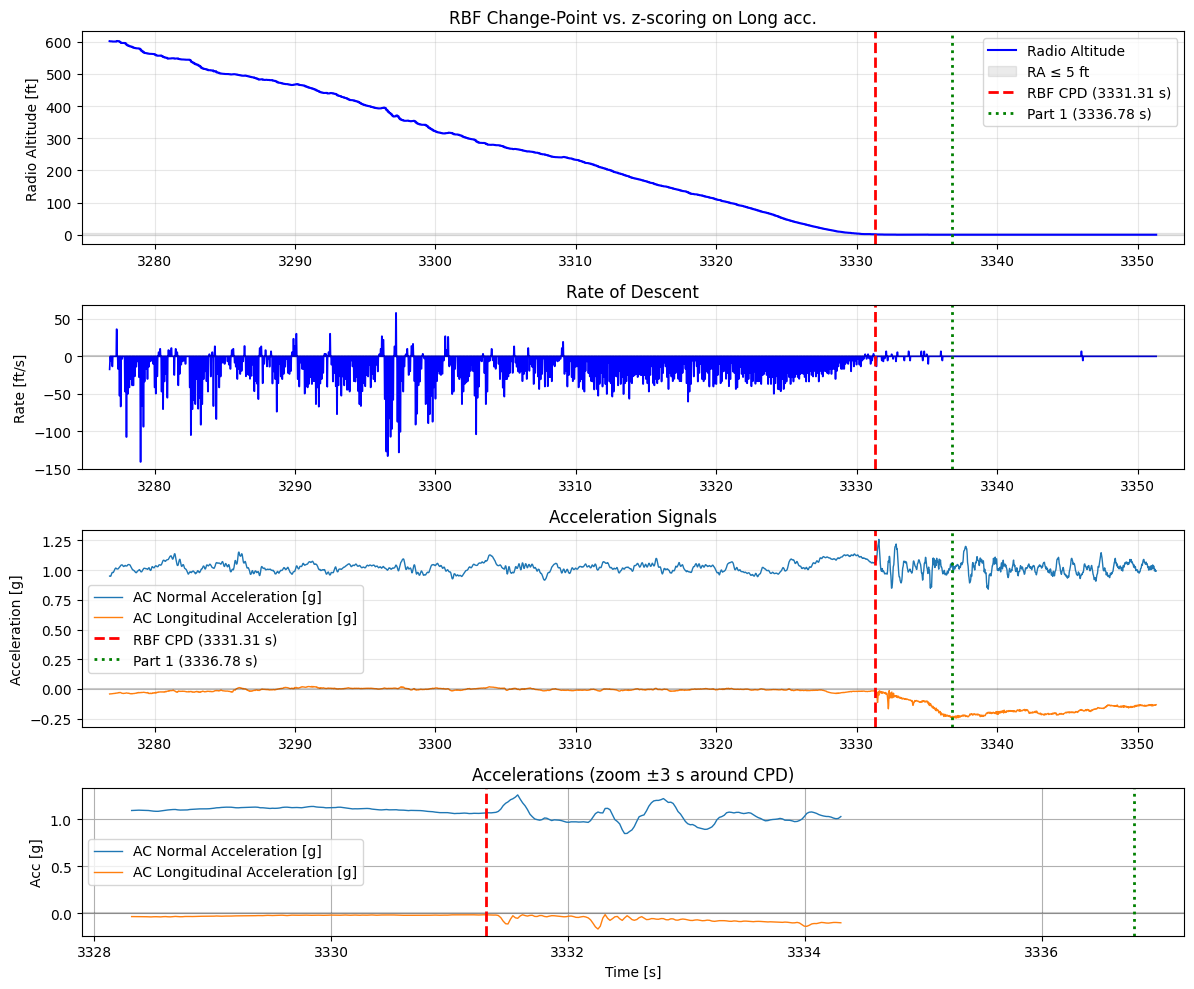


Reconciliation summary:
  CPD time = 3331.31 s, Part-1 time = 3336.78 s, Δt = -5.47 s; CPD uncertainty ≈ ±0.021 s.
  First RA≤5 ft at 3329.61 s (CPD − RA5 = +1.70 s).

✓ Visualization complete.


In [11]:
# 7) Visualize RBF CPD result and reconcile with Part 1 

if 't_cpd' not in globals():
    t_cpd = CPD_TIME_S
if 'dt_med_seg' not in globals():
    dt_med_seg = CPD_T_UNCERT_S

RA_THRESH_FT = 5.0  # near-ground band for visual anchoring

if t_cpd is None:
    print("Cannot visualize: CPD failed.")
else:
    print("Visualizing CPD Result & Comparison with Part 1")
    print("="*60)

    # Time difference
    dt_cpd_vs_part1 = float(t_cpd - float(t_part1))
    print(f"\nTime difference (CPD - Part 1): {dt_cpd_vs_part1:+.2f} s")
    if abs(dt_cpd_vs_part1) <= 1.0:
        print("  → Within ±1 s tolerance (essentially agree)")
    elif abs(dt_cpd_vs_part1) <= 3.0:
        print(f"  → Slight offset (~{abs(dt_cpd_vs_part1):.1f} s). Investigate why.")
    else:
        print(f"  → Significant difference (>{abs(dt_cpd_vs_part1):.1f} s). Check which transient Part 1 locked onto.")

    # First time RA <= 5 ft (if present)
    ra_le_idx = np.where(ra_seg <= RA_THRESH_FT)[0]
    t_ra5 = float(t_seg[ra_le_idx[0]]) if ra_le_idx.size else None
    if t_ra5 is not None:
        print(f"  First RA ≤ {RA_THRESH_FT:.0f} ft at t = {t_ra5:.2f} s (CPD − RA5 = {t_cpd - t_ra5:+.2f} s)")
    else:
        print(f"  RA never drops below {RA_THRESH_FT:.0f} ft inside the segment.")

    # Build figure: RA & dRA/dt & accelerations + a zoom on accelerations
    fig = plt.figure(figsize=(12, 10))
    gs = fig.add_gridspec(4, 1, height_ratios=[1.3, 1.0, 1.2, 0.9])  # last row is zoom
    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[1, 0], sharex=ax0)
    ax2 = fig.add_subplot(gs[2, 0], sharex=ax0)
    ax3 = fig.add_subplot(gs[3, 0])  # zoom

    def mark_times(ax, show_legend=False):
        ax.axvline(t_cpd, color='r', linestyle='--', linewidth=2, label=f'RBF CPD ({t_cpd:.2f} s)')
        # ax.axvspan(t_cpd - dt_med_seg, t_cpd + dt_med_seg, color='r', alpha=0.15, label='CPD ± median Δt')
        ax.axvline(t_part1, color='g', linestyle=':', linewidth=2, label=f'Part 1 ({t_part1:.2f} s)')
        if show_legend:
            ax.legend(loc='upper right')

    # Panel 1: Radio Altitude with near-ground band
    ax0.plot(t_seg, ra_seg, 'b-', linewidth=1.5, label='Radio Altitude')
    if t_ra5 is not None:
        ax0.axhspan(0, RA_THRESH_FT, color='k', alpha=0.08, label=f'RA ≤ {RA_THRESH_FT:.0f} ft')
    mark_times(ax0, show_legend=True)
    ax0.set_ylabel('Radio Altitude [ft]')
    ax0.set_title('RBF Change-Point vs. z-scoring on Long acc.')

    # Panel 2: dRA/dt
    ax1.plot(t_seg, dra_seg, 'b-', linewidth=1.2, label='d(RA)/dt')
    ax1.axhline(0, color='k', linestyle='-', alpha=0.2)
    mark_times(ax1)
    ax1.set_ylabel('Rate [ft/s]')
    ax1.set_title('Rate of Descent')

    # Panel 3: Accelerations
    has_accels = False
    if az_col in df_seg.columns:
        ax2.plot(t_seg, df_seg[az_col].to_numpy(), label=f'{az_col}', linewidth=1.0)
        has_accels = True
    if ax_col in df_seg.columns:
        ax2.plot(t_seg, df_seg[ax_col].to_numpy(), label=f'{ax_col}', linewidth=1.0)
        has_accels = True
    if has_accels:
        ax2.axhline(0, color='k', linestyle='-', alpha=0.2)
        mark_times(ax2)
        ax2.set_ylabel('Acceleration [g]')
        ax2.set_title('Acceleration Signals')
        ax2.legend(loc='best')

    # Panel 4: Zoom on accelerations around CPD (±3 s)
    if has_accels:
        mask_zoom = (t_seg >= t_cpd - 3.0) & (t_seg <= t_cpd + 3.0)
        if az_col in df_seg.columns:
            ax3.plot(t_seg[mask_zoom], df_seg[az_col].to_numpy()[mask_zoom], label=f'{az_col}', linewidth=1.0)
        if ax_col in df_seg.columns:
            ax3.plot(t_seg[mask_zoom], df_seg[ax_col].to_numpy()[mask_zoom], label=f'{ax_col}', linewidth=1.0)
        ax3.axhline(0, color='k', linestyle='-', alpha=0.2)
        ax3.axvline(t_cpd, color='r', linestyle='--', linewidth=2)
        ax3.axvline(t_part1, color='g', linestyle=':', linewidth=2)
        ax3.set_ylabel('Acc [g]')
        ax3.set_xlabel('Time [s]')
        ax3.set_title('Accelerations (zoom ±3 s around CPD)')
        ax3.legend(loc='best')

    # Limits and layout
    pad = 2.0
    ax2.set_xlim(float(t_seg[0]) - pad, float(t_seg[-1]) + pad)


    # Limits and layout
  #  window = 10.0
   # xmin = float(t_cpd) - window
  #  xmax = float(t_cpd) + window
  #  ax2.set_xlim(xmin, xmax)


    for ax in (ax0, ax1, ax2):
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\nReconciliation summary:")
    print(f"  CPD time = {t_cpd:.2f} s, Part-1 time = {t_part1:.2f} s, Δt = {dt_cpd_vs_part1:+.2f} s; "
          f"CPD uncertainty ≈ ±{dt_med_seg:.3f} s.")
    if t_ra5 is not None:
        print(f"  First RA≤{RA_THRESH_FT:.0f} ft at {t_ra5:.2f} s (CPD − RA5 = {t_cpd - t_ra5:+.2f} s).")

    print("\n✓ Visualization complete.")


## 8) Sensitivity Analysis

The robustness of the CPD estimate is tested by re-running the detector on feature subsets (RA + dRA/dt only; accelerations only; RA + each acceleration separately) and sweeping γ by ×0.5, ×1, ×2 around the baseline value.

A spread ≤ ±1 s across all combinations indicates the estimate is stable. Larger spreads imply sensitivity to feature choice and should be carried as an additional uncertainty term in the final summary.

Typical behaviour: RA-only fires during flare (early); accel-only aligns with wheel-strike (later); the blended estimate sits between, reflecting the overall regime change.


In [9]:
# 8) Sensitivity analysis — RBF-CPD robustness 

import numpy as np
import ruptures as rpt

print("RBF-CPD Sensitivity Analysis")
print("="*60)
print(f"Baseline: t_CPD = {CPD_TIME_S:.2f} s (index {CPD_INDEX}), gamma={CPD_GAMMA:.6f}")

# Helper to run CPD on a given Z-subset with a chosen gamma
def _cpd_time_from_Z(Z_sub, gamma, n_bkps=1):
    algo = rpt.KernelCPD(kernel="rbf", params={"gamma": float(gamma)}).fit(Z_sub)
    idx0 = algo.predict(n_bkps=n_bkps)[0] - 1  # 0-based
    return int(idx0), float(t_seg[idx0])

# Build useful feature subsets based on names established in §5
name_to_idx = {name: i for i, name in enumerate(feature_names)}

subsets = []
# RA + dRA/dt
if 'RA [ft]' in name_to_idx and 'd(RA)/dt [ft/s]' in name_to_idx:
    subsets.append((['RA [ft]', 'd(RA)/dt [ft/s]'],
                    [name_to_idx['RA [ft]'], name_to_idx['d(RA)/dt [ft/s]']]))

# Accelerations present?
accels = [n for n in feature_names if n not in ['RA [ft]', 'd(RA)/dt [ft/s]']]
if accels:
    subsets.append((accels, [name_to_idx[n] for n in accels]))
    # RA + each acceleration
    for acc in accels:
        subsets.append((['RA [ft]', acc], [name_to_idx['RA [ft]'], name_to_idx[acc]]))

# Gamma sweep around baseline (keeps scale reasonable)
gamma_multipliers = np.array([0.5, 1.0, 2.0], dtype=float)
all_times = [CPD_TIME_S]  # include baseline for spread calculation

for names, idxs in subsets:
    Z_sub = Z[:, idxs]
    print(f"\nSubset {names}:")
    for m in gamma_multipliers:
        g = float(CPD_GAMMA * m)
        idx_test, t_test = _cpd_time_from_Z(Z_sub, g, n_bkps=1)
        all_times.append(t_test)
        print(f"  gamma× = {m:>4.1f} → t = {t_test:.2f} s (Δt vs baseline {t_test - CPD_TIME_S:+.2f} s)")

# Summarize spread
t_min, t_max = float(np.min(all_times)), float(np.max(all_times))
spread = t_max - t_min
half_spread = spread / 2.0
print("\nSummary:")
print(f"  Min/Max CPD time across tests: {t_min:.2f} / {t_max:.2f} s  (spread = {spread:.2f} s; ±{half_spread:.2f} s)")
print("  Heuristic: if spread ≤ ±1 s, treat the CPD estimate as robust for this dataset.")


RBF-CPD Sensitivity Analysis
Baseline: t_CPD = 3332.15 s (index 2699), gamma=0.075738

Subset ['RA [ft]', 'd(RA)/dt [ft/s]']:
  gamma× =  0.5 → t = 3308.30 s (Δt vs baseline -23.85 s)
  gamma× =  1.0 → t = 3311.60 s (Δt vs baseline -20.55 s)
  gamma× =  2.0 → t = 3312.22 s (Δt vs baseline -19.93 s)

Subset ['AC Normal Acceleration [g]', 'AC Longitudinal Acceleration [g]']:
  gamma× =  0.5 → t = 3333.65 s (Δt vs baseline +1.50 s)
  gamma× =  1.0 → t = 3333.65 s (Δt vs baseline +1.50 s)
  gamma× =  2.0 → t = 3333.65 s (Δt vs baseline +1.50 s)

Subset ['RA [ft]', 'AC Normal Acceleration [g]']:
  gamma× =  0.5 → t = 3310.19 s (Δt vs baseline -21.96 s)
  gamma× =  1.0 → t = 3310.21 s (Δt vs baseline -21.94 s)
  gamma× =  2.0 → t = 3310.23 s (Δt vs baseline -21.92 s)

Subset ['RA [ft]', 'AC Longitudinal Acceleration [g]']:
  gamma× =  0.5 → t = 3332.17 s (Δt vs baseline +0.02 s)
  gamma× =  1.0 → t = 3332.17 s (Δt vs baseline +0.02 s)
  gamma× =  2.0 → t = 3332.17 s (Δt vs baseline +0.02 s)


## 9) Reconciliation Summary

This cell aggregates the final touchdown estimates from both parts, computes timing uncertainties (sampling resolution + sensitivity half-spread), checks the RA context at the CPD instant, and prints a preference statement.


In [10]:
print("\n" + "="*60)
print("PART 2 SUMMARY – TOUCHDOWN ESTIMATES (requires §8)")
print("="*60)

# ----- Guard: ensure §8 ran and exposed sensitivity results -----
needed = ("t_min", "t_max", "spread", "half_spread")
missing = [n for n in needed if n not in globals()]
if missing:
    raise RuntimeError(
        f"Section §8 must be run before §9. Missing variables: {missing}\n"
        "Run the sensitivity cell, then re-run this summary."
    )

# Robust Δt (in case prior cells weren’t re-run in order)
dt_cpd_vs_part1 = float(CPD_TIME_S - float(t_part1))
t_uncert = float(CPD_T_UNCERT_S) if 'CPD_T_UNCERT_S' in globals() else float(np.median(np.diff(t_seg)))

# Context: RA at CPD
ra_at_cpd = float(ra_seg[CPD_INDEX]) if (0 <= CPD_INDEX < len(ra_seg)) else float('nan')
ra_near_zero = (ra_at_cpd <= 5.0)

print(f"\nPart 1 (acceleration-based):")
print(f"  t_part1 = {t_part1:.2f} s")
print(f"  Method: z-score peak on longitudinal acceleration proxy")

print(f"\nPart 2 (RBF-CPD on FDR):")
print(f"  t_cpd   = {CPD_TIME_S:.2f} s")
print(f"  Method: RBF kernel change-point on standardized [RA, dRA/dt, az, ax]")
print(f"  Gamma (RBF): {CPD_GAMMA:.6f}")
print(f"  Timing uncertainty (resolution): ±{t_uncert:.3f} s  (median Δt in segment)")
print(f"  RA at CPD: {ra_at_cpd:.1f} ft  ({'≈0 ft' if ra_near_zero else 'not near 0 ft'})")

print(f"\nComparison:")
print(f"  Δt (CPD − Part-1): {dt_cpd_vs_part1:+.2f} s")

# Sensitivity results from §8
print(f"\nSensitivity (from §8):")
print(f"  Min/Max CPD time: {t_min:.2f} / {t_max:.2f} s")
print(f"  Spread: {spread:.2f} s  (report ±{half_spread:.2f} s in brief)")

# Preference rule: RA context + robustness
if ra_near_zero and half_spread <= 1.0:
    preferred = "Part-2 (RBF-CPD): aligns with RA≈0 ft and is robust (± ≤1 s)"
elif ra_near_zero:
    preferred = "Part-2 (RBF-CPD): aligns with RA≈0 ft (note: sensitivity spread > ±1 s)"
else:
    preferred = "Investigate: CPD not near RA≈0 ft; review segmentation/RA channel"

print(f"\nPreferred estimate (context-based): {preferred}")
print("→ In your brief, cite times, Δt, ±resolution, and ±half-spread; justify preference in one sentence.")
print("\n" + "="*60)



PART 2 SUMMARY – TOUCHDOWN ESTIMATES (requires §8)

Part 1 (acceleration-based):
  t_part1 = 3336.78 s
  Method: z-score peak on longitudinal acceleration proxy

Part 2 (RBF-CPD on FDR):
  t_cpd   = 3332.15 s
  Method: RBF kernel change-point on standardized [RA, dRA/dt, az, ax]
  Gamma (RBF): 0.075738
  Timing uncertainty (resolution): ±0.021 s  (median Δt in segment)
  RA at CPD: 0.5 ft  (≈0 ft)

Comparison:
  Δt (CPD − Part-1): -4.63 s

Sensitivity (from §8):
  Min/Max CPD time: 3308.30 / 3333.65 s
  Spread: 25.35 s  (report ±12.67 s in brief)

Preferred estimate (context-based): Part-2 (RBF-CPD): aligns with RA≈0 ft (note: sensitivity spread > ±1 s)
→ In your brief, cite times, Δt, ±resolution, and ±half-spread; justify preference in one sentence.



## 10) Parameter Summary Table

A consolidated reproducibility record of all analysis parameters — segmentation window, features, CPD method and γ, detected times, and timing uncertainties.


In [11]:
# Build parameter summary table (values already computed earlier)
param_summary = [
    {'Parameter': 'FDR sample rate (median)', 'Value': f'{fs_med:.2f} Hz', 
     'Notes': 'From median dt'},
    {'Parameter': 'Segmentation window', 'Value': f'[{t_start_seg:.2f}, {t_end_seg:.2f}] s', 
     'Notes': f'±{window_pre:.0f}/+{window_post:.0f} s around Part-1'},
    {'Parameter': 'Features included (d)', 'Value': f'{len(feature_names)}', 
     'Notes': ', '.join(feature_names)},
    {'Parameter': 'Standardization', 'Value': 'z-score per feature', 
     'Notes': 'mean=0, std=1'},
    {'Parameter': 'CPD method', 'Value': 'RBF kernel (ruptures)', 
     'Notes': 'KernelCPD(kernel="rbf", params={"gamma": γ})'},
    {'Parameter': 'RBF γ (gamma)', 'Value': f'{CPD_GAMMA:.6f}', 
     'Notes': f'σ ≈ {np.sqrt(0.5/CPD_GAMMA):.4f}'},
    {'Parameter': 'CPD definition', 'Value': 'Regime change', 
     'Notes': 'earliest sustained shift across features'},
    {'Parameter': 'CPD result (index)', 'Value': f'{idx_cpd}', 
     'Notes': f'sample of {len(t_seg)} in segment'},
    {'Parameter': 'CPD result (time)', 'Value': f'{t_cpd:.2f} s', 
     'Notes': 'detected touchdown (Part-2)'},
    {'Parameter': 'Timing uncertainty', 'Value': f'±{CPD_T_UNCERT_S:.3f} s', 
     'Notes': 'median Δt within segment'},
    {'Parameter': 'Part-1 time (accel)', 'Value': f'{t_part1:.2f} s', 
     'Notes': 'z-peak on longitudinal accel proxy'},
    {'Parameter': 'Δt (CPD − Part-1)', 'Value': f'{(t_cpd - t_part1):+.2f} s', 
     'Notes': 'negative ⇒ CPD earlier'},
]

df_params = pd.DataFrame(param_summary)
print("\n" + "="*80)
print("PARAMETER SUMMARY TABLE – PART 2")
print("="*80)
print(df_params.to_string(index=False))
print("\n" + "="*80)



PARAMETER SUMMARY TABLE – PART 2
               Parameter                 Value                                                                                  Notes
FDR sample rate (median)              46.73 Hz                                                                         From median dt
     Segmentation window  [3276.78, 3396.78] s                                                                ±60/+60 s around Part-1
   Features included (d)                     4 RA [ft], d(RA)/dt [ft/s], AC Normal Acceleration [g], AC Longitudinal Acceleration [g]
         Standardization   z-score per feature                                                                          mean=0, std=1
              CPD method RBF kernel (ruptures)                                           KernelCPD(kernel="rbf", params={"gamma": γ})
           RBF γ (gamma)              0.075738                                                                             σ ≈ 2.5694
          CPD definition    

## 11) Integrated Analysis Notes

This section captures the key quantitative findings from both notebooks for use in the written summary.

**Suggested structure for the write-up:**

**1) Aim** (2–4 lines): objective of the spectral sensor comparison (Part 1) and the CPD touchdown refinement (Part 2).

**2) Data & methods** (concise): sampling rates, Welch parameters (fs, nperseg, Δf, #segments), CPD features and γ, segmentation window.

**3) Part 1 results**: PSD level comparison by band; coherence bands (>0.7 shared, <0.3 local); spectral ratio highlights; band-limited RMS values (g, A/B ratio in dB); spectrogram observations.

**4) Part 2 results**: CPD time, Part 1 time, Δt; timing uncertainty (±resolution, ±sensitivity half-spread); RA context at CPD; preference statement with one-line justification.

**5) Limitations**: short post-window → limited Δf; no known excitation → ratios ≠ FRF, coherence ≠ causality; FDR quantisation/latency; CPD sensitivity to feature choice.

**6) Conclusion**: touchdown time with uncertainty; sensor reliability by band; practical implication for future monitoring.
